In [1]:
# Student Exam Score Prediction (Enhanced Version)
# =================================================
# Author: Babak
# Description: Predicting student performance using Student Exam Scores Dataset
# Dataset: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

# STEP 1: Import Libraries
# ------------------------
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
# STEP 2: Load Dataset
# --------------------
df = pd.read_csv("C:\\Users\\Ali\\Desktop\\StudentsPerformance.csv")
print("Initial shape:", df.shape)
df.head()


Initial shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# STEP 3: Data Cleaning
# ---------------------
# Check for nulls
print(df.isnull().sum())

# Encode categorical columns
cat_cols = ['gender','race/ethnicity','parental level of education','lunch','test preparation course']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [4]:
# STEP 4: Feature Engineering
# ---------------------------
# Create target: high performance if average score >= 70
df['average_score'] = df[['math score','reading score','writing score']].mean(axis=1)
df['high_performance'] = (df['average_score'] >= 70).astype(int)

# Drop individual scores if desired
df_clean = df.drop(columns=['math score','reading score','writing score','average_score'])
print("Clean dataset shape:", df_clean.shape)


Clean dataset shape: (1000, 6)


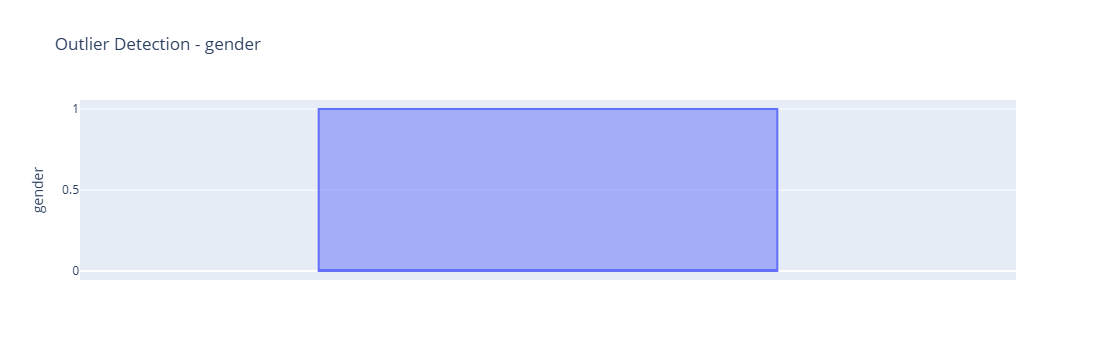

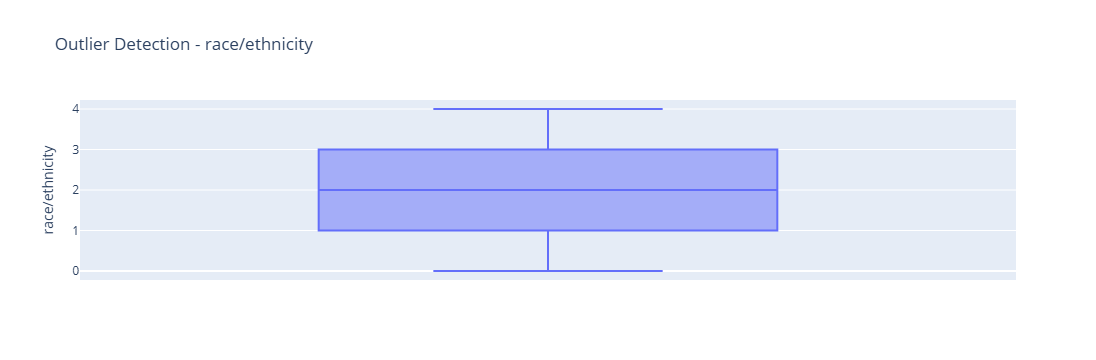

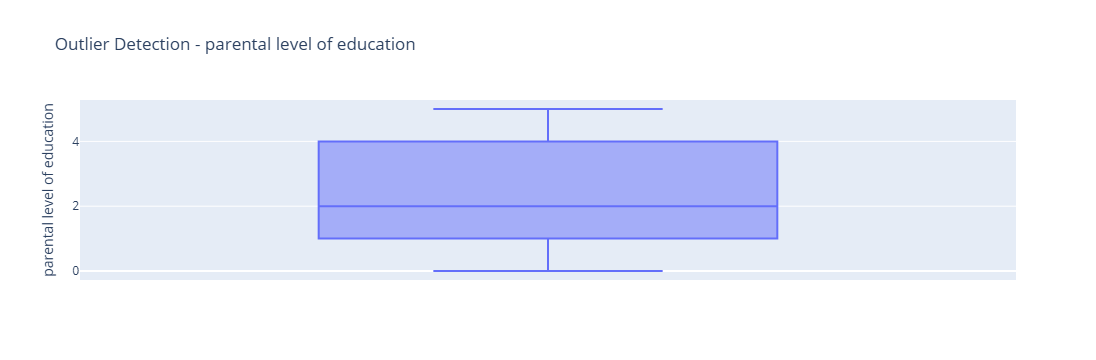

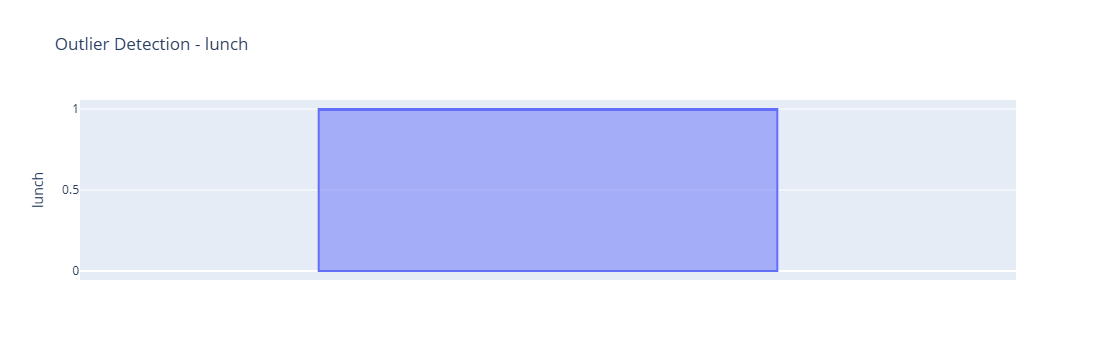

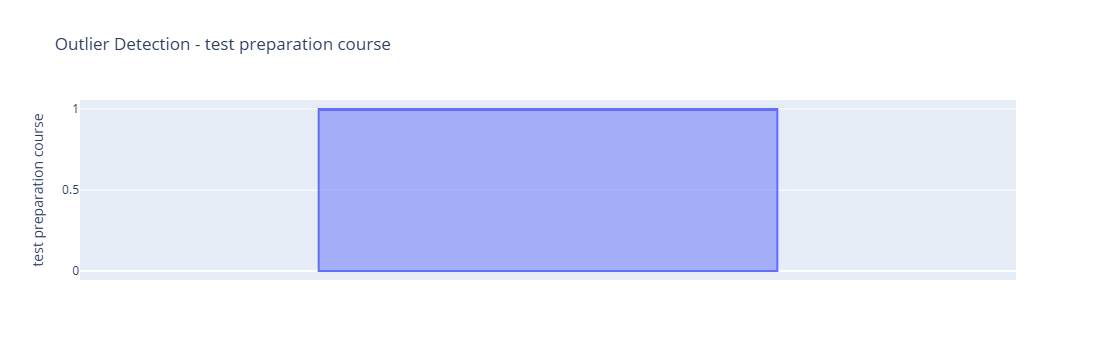

In [5]:
# STEP 5: Outlier Detection with Box Plots
# ----------------------------------------
numeric_cols = ['gender','race/ethnicity','parental level of education','lunch','test preparation course']
for col in numeric_cols:
    fig = px.box(df_clean, y=col, points="outliers", title=f"Outlier Detection - {col}")
    fig.show()



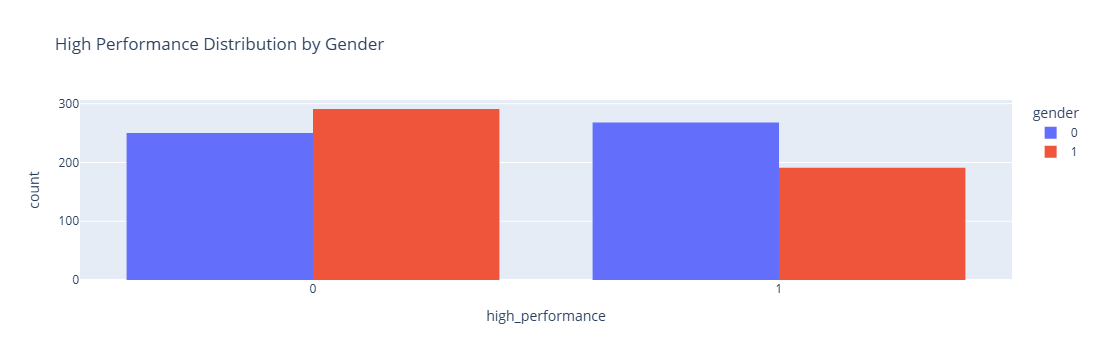

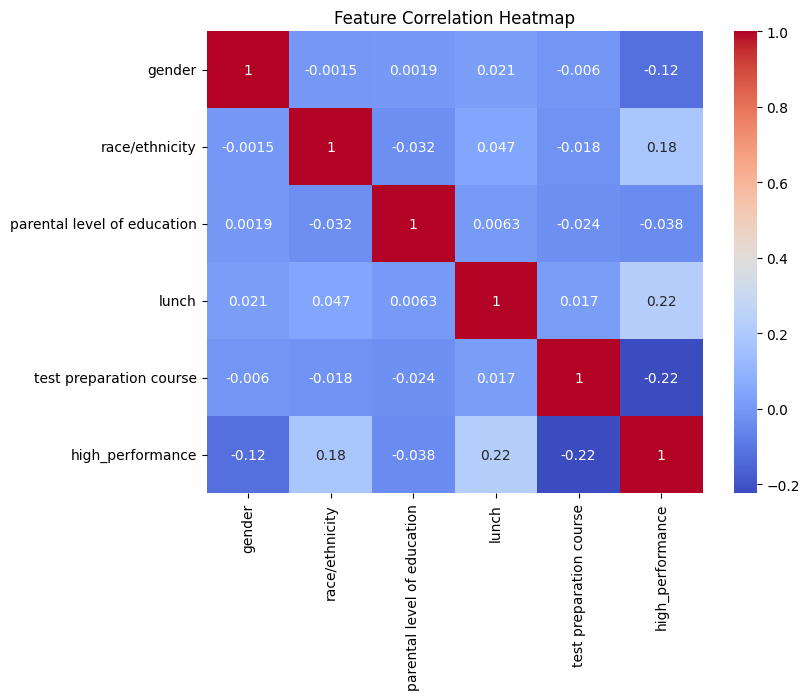

In [6]:
# STEP 6: Exploratory Data Analysis
# ---------------------------------
# Distribution of high performance
fig1 = px.histogram(df_clean, x="high_performance", color="gender", barmode="group",
                    title="High Performance Distribution by Gender")
fig1.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [7]:
# STEP 7: Prepare Data for ML
# ---------------------------
X = df_clean.drop(columns=['high_performance'])
y = df_clean['high_performance']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [8]:
# STEP 8: Train Model
# -------------------
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.69      0.65       108
           1       0.57      0.47      0.51        92

    accuracy                           0.59       200
   macro avg       0.59      0.58      0.58       200
weighted avg       0.59      0.59      0.58       200



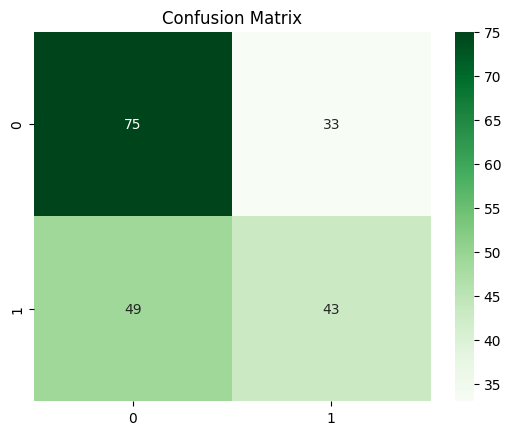

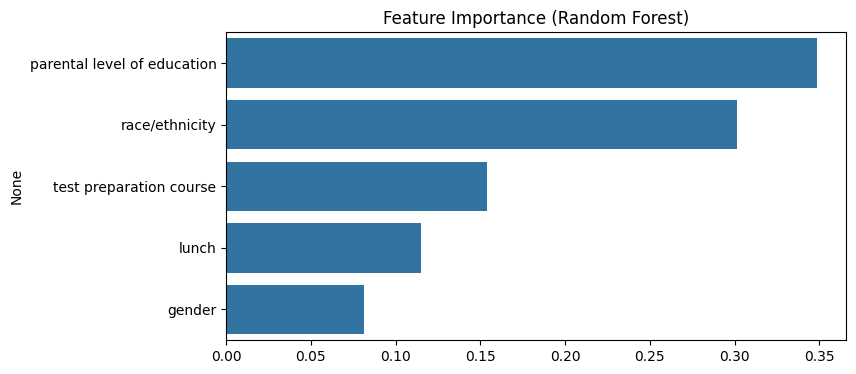

In [9]:
# STEP 9: Evaluation
# ------------------
y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix")
plt.show()

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [10]:
# STEP 10: Save Model and Scaler
# -------------------------------
joblib.dump(model, "student_performance_model.pkl")
joblib.dump(scaler, "student_scaler.pkl")
print("Model and scaler saved successfully.")


Model and scaler saved successfully.
